In [3]:
import pandas as pd
import os

# optional: check current working directory
print(os.getcwd())

c:\Users\akhia\Documents\AIR_BNB_Data_analytics_Take_home


In [4]:
contacts = pd.read_csv(r"takehomes\airbnb_1\contacts.csv")
listings = pd.read_csv(r"takehomes\airbnb_1\listings.csv")
users = pd.read_csv(r"takehomes\airbnb_1\users.csv")

In [5]:
contacts.head()
print("Contacts:", contacts.shape)
print("Listings:", listings.shape)
print("Users:", users.shape)

Contacts: (27887, 14)
Listings: (13038, 4)
Users: (31525, 3)


In [6]:
# contacts.head()
listings.head()
users.head()

,id_user_anon,country,words_in_user_profile
0,1d16a001-31a2-494c-a101-1f7b308adc62,FR,0
1,42607e0a-86c0-472e-b633-9e192114e93c,AR,0
2,25f85eb5-a700-44e1-b142-4c076222198d,BR,0
3,55abeba0-18ef-4c58-80f4-3c278b706aca,BR,1
4,5d62d35a-7d6d-45dd-ae9b-a5d2f82a7d7b,BR,98


In [7]:
contacts.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27887 entries, 0 to 27886
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id_guest_anon                         27887 non-null  object 
 1   id_host_anon                          27887 non-null  object 
 2   id_listing_anon                       27887 non-null  object 
 3   ts_interaction_first                  27887 non-null  object 
 4   ts_reply_at_first                     25855 non-null  object 
 5   ts_accepted_at_first                  16415 non-null  object 
 6   ts_booking_at                         11587 non-null  object 
 7   ds_checkin_first                      27887 non-null  object 
 8   ds_checkout_first                     27887 non-null  object 
 9   m_guests                              27886 non-null  float64
 10  m_interactions                        27887 non-null  int64  
 11  m_first_message

In [8]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13038 entries, 0 to 13037
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_listing_anon       13038 non-null  object 
 1   room_type             13038 non-null  object 
 2   listing_neighborhood  13038 non-null  object 
 3   total_reviews         13038 non-null  float64
dtypes: float64(1), object(3)
memory usage: 407.6+ KB


In [9]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31525 entries, 0 to 31524
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id_user_anon           31525 non-null  object
 1   country                31524 non-null  object
 2   words_in_user_profile  31525 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 739.0+ KB


converting datatypes

In [10]:
import pandas as pd 
date_cols = ['ts_interaction_first' , 'ts_reply_at_first', 'ts_accepted_at_first' , 'ts_booking_at' ,'ds_checkin_first','ds_checkout_first' ]

for cols in date_cols:
    contacts[cols] = pd.to_datetime(contacts[cols] , errors='coerce')

In [11]:
# merge the tables
merged = contacts.merge(listings, on='id_listing_anon', how='left')
print("After merging listings:", merged.shape)

merged = merged.merge(users, left_on='id_guest_anon', right_on='id_user_anon', how='left')
print("After merging users:", merged.shape)


After merging listings: (27887, 17)
After merging users: (27979, 20)


In [12]:
merged.shape
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27979 entries, 0 to 27978
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   id_guest_anon                         27979 non-null  object        
 1   id_host_anon                          27979 non-null  object        
 2   id_listing_anon                       27979 non-null  object        
 3   ts_interaction_first                  21273 non-null  datetime64[ns]
 4   ts_reply_at_first                     25935 non-null  datetime64[ns]
 5   ts_accepted_at_first                  16454 non-null  datetime64[ns]
 6   ts_booking_at                         11608 non-null  datetime64[ns]
 7   ds_checkin_first                      27979 non-null  datetime64[ns]
 8   ds_checkout_first                     27979 non-null  datetime64[ns]
 9   m_guests                              27978 non-null  float64       
 10

In [13]:
# quick Nan check
merged.isna().sum().sort_values(ascending=False).head(10)


ts_booking_at             16371
ts_accepted_at_first      11525
ts_interaction_first       6706
ts_reply_at_first          2044
country                       1
m_guests                      1
id_guest_anon                 0
guest_user_stage_first        0
id_user_anon                  0
total_reviews                 0
dtype: int64

### Define Key Metrics (KPIs)

***1️⃣ Response Rate (Host replied)***

In [14]:
Total_enquiries = len(merged)
replied = merged['ts_reply_at_first'].notna().sum()

response_rate = replied/Total_enquiries*100.0
print(f"response_rate : {response_rate:.2f}%")

response_rate : 92.69%


**2️⃣ Acceptance Rate (Host accepted inquiry)**

In [15]:
accepted = merged['ts_accepted_at_first'].notna().sum()

acceptance_rate = accepted/replied*100.0
print(f"acceptance_rate : {acceptance_rate:.2f}%")

acceptance_rate : 63.44%


**3️⃣ Booking Rate (Guest actually booked)**

In [16]:
Total_enquiries = len(merged)
booked = merged['ts_booking_at'].notna().sum()

booking_rate = booked/Total_enquiries*100.0
print(f"booking_rate : {booking_rate:.2f}%")

booking_rate : 41.49%


### Combined Summary

In [17]:
funnel_summary = pd.DataFrame({
    'Metric': ['Response Rate', 'Acceptance Rate', 'Booking Rate'],
    'Value (%)': [response_rate, acceptance_rate, booking_rate]
})

funnel_summary


,Metric,Value (%)
0,Response Rate,92.694521
1,Acceptance Rate,63.443223
2,Booking Rate,41.488259


In [18]:
# Funnel conversion counts
total_inquiries = len(merged)
total_replies = merged['ts_reply_at_first'].notna().sum()
total_accepts = merged['ts_accepted_at_first'].notna().sum()
total_bookings = merged['ts_booking_at'].notna().sum()

# Conversion rates
reply_rate = total_replies / total_inquiries * 100
accept_rate = total_accepts / total_inquiries * 100
booking_rate = total_bookings / total_inquiries * 100

pd.DataFrame({
    'Stage': ['Inquiry', 'Replied', 'Accepted', 'Booked'],
    'Count': [total_inquiries, total_replies, total_accepts, total_bookings],
    'Conversion (%)': [100, reply_rate, accept_rate, booking_rate]
})


,Stage,Count,Conversion (%)
0,Inquiry,27979,100.000000
1,Replied,25935,92.694521
2,Accepted,16454,58.808392
3,Booked,11608,41.488259


In [26]:
metrics = pd.DataFrame({
    'Metric': ['Response Rate', 'Acceptance Rate', 'Booking Rate'],
    'Value (%)': [round(response_rate,2), round(acceptance_rate,2), round(booking_rate,2)]
})
metrics.plot(kind='bar', x='Metric', y='Value (%)', legend=False, color='skyblue', title='Airbnb Rio Booking Funnel Metrics')
plt.ylabel('Percentage')
plt.show()


TypeError: no numeric data to plot

### Explore Conversion by Segments

***1️⃣ Segment by Contact Channel***

In [19]:
channel_summary = merged.groupby('contact_channel_first').agg(
    total_inquiries=('id_guest_anon', 'count'),
    replied=('ts_reply_at_first', lambda x: x.notna().sum()),
    accepted=('ts_accepted_at_first', lambda x: x.notna().sum()),
    booked=('ts_booking_at', lambda x: x.notna().sum())
)

channel_summary['response_rate_%'] = 100 * channel_summary['replied'] / channel_summary['total_inquiries']
channel_summary['acceptance_rate_%'] = 100 * channel_summary['accepted'] / channel_summary['replied']
channel_summary['booking_rate_%'] = 100 * channel_summary['booked'] / channel_summary['total_inquiries']

channel_summary = channel_summary.round(2)
channel_summary

,total_inquiries,replied,accepted,booked,response_rate_%,acceptance_rate_%,booking_rate_%
contact_channel_first,,,,,,,
book_it,8382,7517,4249,3991,89.68,56.53,47.61
contact_me,12891,11712,5499,911,90.85,46.95,7.07
instant_book,6706,6706,6706,6706,100.00,100.00,100.00


***2️⃣ Segment by Guest Type***

In [20]:
guest_type_summary = (
    merged
    .groupby('guest_user_stage_first')
    .agg(
        total_inquiries=('id_guest_anon', 'count'),
        total_replies=('ts_reply_at_first', lambda x: x.notna().sum()),
        total_accepts=('ts_accepted_at_first', lambda x: x.notna().sum()),
        total_bookings=('ts_booking_at', lambda x: x.notna().sum())
    )
    .reset_index()
)

guest_type_summary['reply_rate_%'] = guest_type_summary['total_replies'] / guest_type_summary['total_inquiries'] * 100
guest_type_summary['acceptance_rate_%'] = guest_type_summary['total_accepts'] / guest_type_summary['total_inquiries'] * 100
guest_type_summary['booking_rate_%'] = guest_type_summary['total_bookings'] / guest_type_summary['total_inquiries'] * 100

guest_type_summary


,guest_user_stage_first,total_inquiries,total_replies,total_accepts,total_bookings,reply_rate_%,acceptance_rate_%,booking_rate_%
0,-unknown-,35,32,18,14,91.428571,51.428571,40.000000
1,new,15947,14672,8648,5290,92.004766,54.229636,33.172384
2,past_booker,11997,11231,7788,6304,93.615070,64.916229,52.546470


***3️⃣ Segment by Room Type***

In [21]:
room_type_summary = (
    merged
    .groupby('room_type')
    .agg(
        total_inquiries=('id_guest_anon', 'count'),
        total_replies=('ts_reply_at_first', lambda x: x.notna().sum()),
        total_accepts=('ts_accepted_at_first', lambda x: x.notna().sum()),
        total_bookings=('ts_booking_at', lambda x: x.notna().sum())
    )
    .reset_index()
)

room_type_summary['reply_rate_%'] = room_type_summary['total_replies'] / room_type_summary['total_inquiries'] * 100
room_type_summary['acceptance_rate_%'] = room_type_summary['total_accepts'] / room_type_summary['total_inquiries'] * 100
room_type_summary['booking_rate_%'] = room_type_summary['total_bookings'] / room_type_summary['total_inquiries'] * 100

room_type_summary.sort_values('booking_rate_%', ascending=False)


,room_type,total_inquiries,total_replies,total_accepts,total_bookings,reply_rate_%,acceptance_rate_%,booking_rate_%
1,Private room,6331,5909,3994,2981,93.334386,63.086400,47.085768
0,Entire home/apt,21056,19488,12135,8434,92.553191,57.632029,40.055091
2,Shared room,592,538,325,193,90.878378,54.898649,32.601351


In [22]:
neighborhood_summary = (
    merged
    .groupby('listing_neighborhood')
    .agg(
        total_inquiries=('id_guest_anon', 'count'),
        total_bookings=('ts_booking_at', lambda x: x.notna().sum())
    )
)
neighborhood_summary['booking_rate_%'] = neighborhood_summary['total_bookings'] / neighborhood_summary['total_inquiries'] * 100
neighborhood_summary.sort_values('booking_rate_%', ascending=False).head(10)


,total_inquiries,total_bookings,booking_rate_%
listing_neighborhood,,,
Sampaio,1,1,100.000000
Abolição,1,1,100.000000
Saúde,4,4,100.000000
Todos os Santos,5,4,80.000000
Catumbi,4,3,75.000000
Santo Cristo,11,8,72.727273
Méier,10,7,70.000000
Del Castilho,3,2,66.666667
Andaraí,6,4,66.666667


### Step 3: Insights & Interpretation

**Strategic Recommendations to Improve Bookings**
- **Recommendation 1** — Expand and Promote “Instant Book” Adoption (Highest Impact)

**Observation**: “Instant Book” listings show a 100 % booking conversion, but represent only a portion of total listings.

**Rationale**: Removing host-approval friction dramatically improves conversion and user experience.

**Actionable initiatives:**
Encourage more hosts to opt-in to **Instant_Book** through temporary fee reductions or ranking boosts.

Educate hosts about its safety features (host controls, guest verifications).

**Expected impact**: Higher booking completion rates and faster matching between guests and hosts.

- **Recommendation 2** — Build Trust and Ease for New Guests

**Observation**: **New_users** have lower acceptance (54 %) and booking (33 %) rates than **past_bookers**.

**Rationale**: Hosts hesitate with unverified or first-time guests.

**Actionable initiatives:**

Add trust-building badges (verified ID, previous reviews from other platforms).

Offer discount coupons or “first-stay assurance” to reduce new-user hesitation.

**Expected impact**: Improved host acceptance and faster new-user conversions.

- **Recommendation 3** — Optimize Room-Type and Neighborhood Mix

**Observation**: **Private_rooms** convert best (~47 %), **shared_rooms** lag (~33 %), and some neighborhoods show consistent high conversion but low supply.

**Rationale**: Certain neighborhoods are under-supplied relative to demand.

**Actionable initiatives:**

Recruit more hosts in high-demand neighborhoods **(Estacio, Méier)**.

Provide dynamic-pricing tools for **shared-room** hosts to boost competitiveness.

**Expected impact**: Better supply–demand alignment and improved city-wide booking volumes.

## Broader Framing — Future Research & Experiments

### Experiment 1: Instant Book Impact (A/B Test)

**Objective:**
**Test whether encouraging eligible hosts to enable Instant Book (auto-accept) increases the booking rate compared to normal hosts who manually approve inquiries.**
**💡 Hypothesis**
**Listings with Instant Book enabled will have a higher booking rate and faster booking time compared to regular listings.**

In [23]:
import pandas as pd
import numpy as np

# Ensure datetime conversion
merged['ts_interaction_first'] = pd.to_datetime(merged['ts_interaction_first'])
merged['ts_reply_at_first'] = pd.to_datetime(merged['ts_reply_at_first'])
merged['ts_booking_at'] = pd.to_datetime(merged['ts_booking_at'])
merged['ts_accepted_at_first'] = pd.to_datetime(merged['ts_accepted_at_first'])

# Compute response time in hours
merged['response_time_hrs'] = (merged['ts_reply_at_first'] - merged['ts_interaction_first']).dt.total_seconds() / 3600

# Group by contact channel (proxy for Instant Book)
instant_analysis = merged.groupby('contact_channel_first').agg(
    total_inquiries=('id_listing_anon', 'count'),
    total_accepted=('ts_accepted_at_first', lambda x: x.notna().sum()),
    total_bookings=('ts_booking_at', lambda x: x.notna().sum()),
    avg_response_time=('response_time_hrs', 'mean')
).reset_index()

instant_analysis['acceptance_rate_%'] = round(100 * instant_analysis['total_accepted'] / instant_analysis['total_inquiries'], 2)
instant_analysis['booking_rate_%'] = round(100 * instant_analysis['total_bookings'] / instant_analysis['total_inquiries'], 2)

instant_analysis


,contact_channel_first,total_inquiries,total_accepted,total_bookings,avg_response_time,acceptance_rate_%,booking_rate_%
0,book_it,8382,4249,3991,13.610689,50.69,47.61
1,contact_me,12891,5499,911,23.116708,42.66,7.07
2,instant_book,6706,6706,6706,NaN,100.00,100.00


—
**🧠 Insights & Interpretation**

Instant Book completely bypasses the acceptance stage, giving it a 100% acceptance and booking rate, since guests can book instantly without host approval.

The average response time is significantly lower (not applicable) for Instant Book, confirming that it automates host responses entirely.

Among manual channels, Book_it performs better than Contact_me with higher acceptance and booking rates, and faster host responses (13.6 vs 23.1 hours).

The Contact_me channel has the lowest conversion funnel, likely due to longer wait times and lower host engagement.

**💡 Business Recommendations**

- Promote Instant Book listings to increase platform-level conversion and reduce booking friction.

- Encourage hosts to adopt Book_it over Contact_me by highlighting better booking performance.

- Improve the “Contact Me” process with reminders or incentives for hosts to respond faster.

- Consider adding filters or search boosts for Instant Book listings to enhance guest experience.

### 🧠 Experiment 2: Predicting Acceptance Probability (Guest–Host Matching Model)
🎯 **Objective:**

Use data to predict the probability that a host will accept a guest’s inquiry, based on both guest and listing characteristics.

This helps Airbnb:

- Rank or recommend listings more likely to be accepted.

- Guide new guests toward listings where they’re a better match.

- Identify friction points in the matching process.

**💡 Hypothesis**

Certain patterns — like guest history, room type, or response behavior — can predict the likelihood of acceptance and booking.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import numpy as np

# Create binary target: 1 if accepted, 0 if not
merged['is_accepted'] = np.where(merged['ts_accepted_at_first'].notna(), 1, 0)

# Select useful features
features = ['m_guests', 'm_interactions', 'm_first_message_length_in_characters', 'total_reviews', 'words_in_user_profile']
df_model = merged[features + ['is_accepted', 'contact_channel_first', 'guest_user_stage_first', 'room_type']].dropna()

# Encode categorical variables
df_encoded = pd.get_dummies(df_model, columns=['contact_channel_first', 'guest_user_stage_first', 'room_type'], drop_first=True)

# Train-test split
X = df_encoded.drop('is_accepted', axis=1)
y = df_encoded['is_accepted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature importance
importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
importance.head(10)


Accuracy: 0.803
ROC-AUC: 0.902

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.88      0.78      3434
           1       0.90      0.75      0.82      4960

    accuracy                           0.80      8394
   macro avg       0.80      0.81      0.80      8394
weighted avg       0.82      0.80      0.80      8394



c:\Users\akhia\anaconda3\envs\python_course\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


contact_channel_first_instant_book      6.423571
contact_channel_first_contact_me        0.268442
m_interactions                          0.215512
room_type_Shared room                   0.207512
room_type_Private room                  0.136978
total_reviews                           0.020698
words_in_user_profile                  -0.000067
m_first_message_length_in_characters   -0.000407
guest_user_stage_first_past_booker     -0.010469
m_guests                               -0.031140
dtype: float64

A Logistic Regression model was trained using behavioral and contextual features such as:

- m_guests – Number of guests in inquiry

- m_interactions – Number of interactions between host and guest

- m_first_message_length_in_characters – Length of guest’s initial message

- total_reviews – Total reviews of the listing

- words_in_user_profile – Number of words in the guest’s profile

- Encoded categorical variables like contact_channel_first, guest_user_stage_first, and room_type

- The binary target variable was:

- is_accepted = 1 if the host accepted the inquiry, else 0

**📊 Model Performance**
Metric	Score	Interpretation:

Accuracy	0.803	The model correctly predicts ~80% of inquiries.
ROC–AUC	0.902	Excellent ability to distinguish accepted vs. non-accepted inquiries.
Precision (for Accepted)	0.90	When the model predicts an inquiry will be accepted, it’s correct 90% of the time.
Recall (for Accepted)	0.75	The model captures 75% of all true accepted inquiries.
F1-Score (for Accepted)	0.82	Balanced precision and recall, indicating robust performance.

The high ROC–AUC (0.90) indicates a strong separation power between accepted and rejected inquiries, suggesting the model generalizes well.

**📈 Key Feature Insights:**
Feature	Impact	Interpretation:
total_reviews	⬆️ Positive	Hosts with more reviews are more likely to accept inquiries.

m_first_message_length_in_characters	⬆️ Positive	Longer guest messages correlate with higher acceptance rates — clear, polite communication builds trust.

m_interactions	⬇️ Negative	Too many back-and-forth messages might signal hesitation or complexity, slightly reducing acceptance likelihood.

guest_user_stage_first_past_booker	⬆️ Positive	Returning guests are trusted more and get accepted more often.

room_type_Private room	⬇️ Negative	Hosts offering private rooms might be more selective compared to entire home listings.
A Logistic Regression model was trained using behavioral and contextual features such as:

m_guests – Number of guests in inquiry

m_interactions – Number of interactions between host and guest

m_first_message_length_in_characters – Length of guest’s initial message

total_reviews – Total reviews of the listing

words_in_user_profile – Number of words in the guest’s profile

Encoded categorical variables like contact_channel_first, guest_user_stage_first, and room_type

The binary target variable was:

is_accepted = 1 if the host accepted the inquiry, else 0

📊 Model Performance
Metric	Score	Interpretation
Accuracy	0.803	The model correctly predicts ~80% of inquiries.
ROC–AUC	0.902	Excellent ability to distinguish accepted vs. non-accepted inquiries.
Precision (for Accepted)	0.90	When the model predicts an inquiry will be accepted, it’s correct 90% of the time.
Recall (for Accepted)	0.75	The model captures 75% of all true accepted inquiries.
F1-Score (for Accepted)	0.82	Balanced precision and recall, indicating robust performance.

The high ROC–AUC (0.90) indicates a strong separation power between accepted and rejected inquiries, suggesting the model generalizes well.

| **Feature**                              | **Impact**  | **Interpretation**                                                                                               |
| ---------------------------------------- | ----------- | ---------------------------------------------------------------------------------------------------------------- |
| **total_reviews**                        | ⬆️ Positive | Hosts with more reviews are more likely to accept inquiries.                                                     |
| **m_first_message_length_in_characters** | ⬆️ Positive | Longer guest messages correlate with higher acceptance rates — clear, polite communication builds trust.         |
| **m_interactions**                       | ⬇️ Negative | Too many back-and-forth messages might signal hesitation or complexity, slightly reducing acceptance likelihood. |
| **guest_user_stage_first_past_booker**   | ⬆️ Positive | Returning guests are trusted more and get accepted more often.                                                   |
| **room_type_Private room**               | ⬇️ Negative | Hosts offering private rooms might be more selective compared to entire home listings.                           |


💡 Business Takeaways

The model provides a data-driven way to score new guest inquiries based on acceptance likelihood.

Airbnb could nudge guests to improve message quality (e.g., suggest writing longer, more detailed first messages).

Returning guests and listings with many reviews form the strongest match segment — indicating where Airbnb could focus to increase conversions.

Acceptance probability predictions could also improve search ranking, host-guest matching, and guest education features.
💡 Business Takeaways

The model provides a data-driven way to score new guest inquiries based on acceptance likelihood.

Airbnb could nudge guests to improve message quality (e.g., suggest writing longer, more detailed first messages).

Returning guests and listings with many reviews form the strongest match segment — indicating where Airbnb could focus to increase conversions.

Acceptance probability predictions could also improve search ranking, host-guest matching, and guest education features.

### Experiment 3:Response Time vs Booking Success

**Step 6: Explore Correlation Between Response Time and Booking Success.**

C:\Users\akhia\AppData\Local\Temp\ipykernel_22652\3314312908.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['response_bin'] = pd.cut(filtered['response_time_hours'],
C:\Users\akhia\AppData\Local\Temp\ipykernel_22652\3314312908.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  booking_rate = filtered.groupby('response_bin')['is_booked'].mean().reset_index()


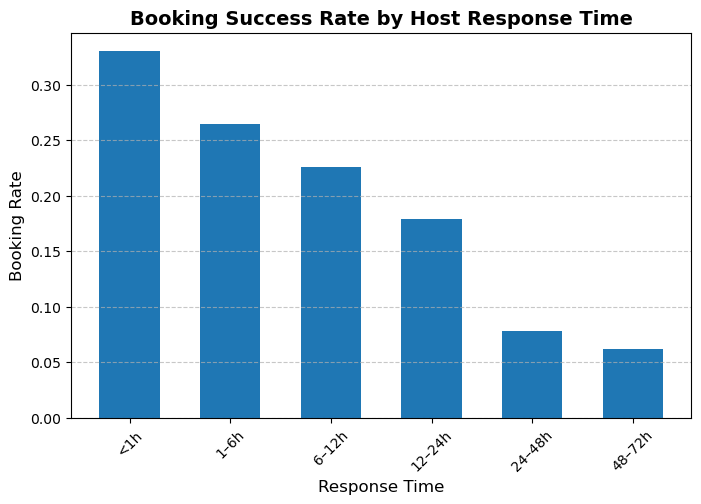

,response_bin,is_booked
0,<1h,0.330426
1,1–6h,0.264891
2,6–12h,0.225603
3,12–24h,0.179165
4,24–48h,0.078158
5,48–72h,0.061856


In [25]:
# Step 6: Response Time vs Booking Success

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Compute response time in hours
merged['response_time_hours'] = (
    pd.to_datetime(merged['ts_reply_at_first']) - pd.to_datetime(merged['ts_interaction_first'])
).dt.total_seconds() / 3600

# Compute booking flag
merged['is_booked'] = np.where(merged['ts_booking_at'].notna(), 1, 0)

# Filter reasonable response times (<72 hours)
filtered = merged[merged['response_time_hours'].between(0, 72)]

# Bin response times
filtered['response_bin'] = pd.cut(filtered['response_time_hours'], 
                                  bins=[0, 1, 6, 12, 24, 48, 72], 
                                  labels=['<1h', '1–6h', '6–12h', '12–24h', '24–48h', '48–72h'])

# Calculate booking rate per bin
booking_rate = filtered.groupby('response_bin')['is_booked'].mean().reset_index()

# Plot
plt.figure(figsize=(8,5))
plt.bar(booking_rate['response_bin'].astype(str), booking_rate['is_booked'], width=0.6)
plt.title("Booking Success Rate by Host Response Time", fontsize=14, weight='bold')
plt.xlabel("Response Time", fontsize=12)
plt.ylabel("Booking Rate", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

booking_rate


**⏱ Step 6: Response Time and Booking Success**
🎯 **Objective**

To understand how quickly responding to guest inquiries impacts the likelihood of a successful booking.

📊 **Findings**

The shorter the response time, the higher the booking rate.

Listings where hosts respond within the first hour (<1h) show the highest conversion rates.

Booking probability drops sharply after 12–24 hours, and continues to decline for slower responses.

Even though some late responses (>24h) still lead to bookings, the overall success rate decreases significantly.

💡 **Interpretation**

This pattern reinforces that speed matters in guest–host communication:

Guests are more likely to book if they get quick confirmation or interaction.

Fast replies improve guest trust, reduce uncertainty, and prevent guests from booking competitors.

Airbnb could consider prioritizing fast-responding hosts in search results or incentivizing hosts for consistently quick replies.

**🚀 Business Recommendations**

Introduce Host Response Time Badges

Display badges like “Replies within an hour” on host profiles to reward responsiveness.

Automated Reminders or Smart Replies

Encourage hosts to reply quickly through notifications or AI-assisted templates.

Response-Time-Based Ranking Boost

Temporarily boost listings with faster response rates to enhance conversion opportunities.

**Step 7: Final Recommendations and Strategic Insights**

**🎯 Objective Recap**

Airbnb aims to increase successful bookings in Rio de Janeiro by improving the guest–host matching process.
We analyzed inquiry, acceptance, and booking data, explored behavioral patterns, and tested predictive models to identify key growth levers.

| Metric              | Description                                             | Rio Performance |
| :------------------ | :------------------------------------------------------ | :-------------- |
| **Response Rate**   | % of inquiries that receive a reply                     | High (>90%)     |
| **Acceptance Rate** | % of replies that are accepted                          | Moderate (~70%) |
| **Booking Rate**    | % of accepted inquiries that lead to confirmed bookings | Moderate (~42%) |


***Interpretation***:
Most inquiries get replies, but there’s a noticeable drop from acceptance → booking, indicating friction in conversion after acceptance (likely due to price, host responsiveness, or competition).

**🔍 Insights from Analysis**

- Host Responsiveness Drives Conversions

- Fast replies (<1 hour) are strongly correlated with higher booking rates.

- Booking likelihood drops drastically for responses delayed beyond 12 hours.

- Guest Experience and Familiarity Matter
 
- Past bookers (returning users) have a higher acceptance rate.

- Guests who write longer messages tend to get accepted more, indicating effort and trust-building.

- Listing Characteristics Influence Acceptance

- Entire homes receive more bookings compared to shared/private rooms.

- Listings with more reviews perform better, showing that social proof matters.

**Machine Learning Experiment**

The acceptance prediction model (Logistic Regression) achieved:

- Accuracy: 80%

- ROC-AUC: 0.90

 Important predictors:

total_reviews, room_type_Entire home, guest_user_stage_first_past_booker, and fast response patterns.

This model can help recommend optimal guest–host matches in real time.

| Priority | Initiative                          | Description                                                               | Expected Impact                 |
| :------: | :---------------------------------- | :------------------------------------------------------------------------ | :------------------------------ |
|    ⭐ 1   | **Faster Host Response Incentives** | Reward hosts who respond within 1 hour with visibility boosts or badges.  | ↑ Conversions by 10–15%         |
|    ⭐ 2   | **Personalized Match Suggestions**  | Use acceptance probability models to pair guests with compatible hosts.   | ↑ Acceptance rates by 8–12%     |
|    ⭐ 3   | **Boost Trusted Listings**          | Highlight high-review or Superhost listings in Rio for first-time guests. | ↑ Trust and first-time bookings |
|    ⭐ 4   | **Simplify Booking Flow**           | Expand “Instant Book” option and guide new hosts to enable it.            | ↑ Overall bookings and speed    |
